# Task 4: Open-set recognition on CIFAR



In [ ]:
import os, json, random, copy, platform
from pathlib import Path
import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.nn import functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision
from torchvision import transforms as T
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from scipy.stats import spearmanr
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from google.colab import drive

drive.mount('/content/drive')
ROOT=Path('/content/drive/MyDrive/ATML_PA1/Task4_CIFAR_OSR')
MODELS=ROOT/'checkpoints'; ARRAYS=ROOT/'arrays'; RESULTS=ROOT/'results'
for folder in (MODELS, ARRAYS, RESULTS): folder.mkdir(parents=True,exist_ok=True)
DEVICE=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
assert DEVICE.type=='cuda', 'Select a GPU runtime in Colab.'
SEED=6304

def set_seed(seed=SEED):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic=True
    torch.backends.cudnn.benchmark=False
set_seed()
print('GPU:',torch.cuda.get_device_name(0),'| Torch:',torch.__version__,'| torchvision:',torchvision.__version__)


Mounted at /content/drive
GPU: NVIDIA A100-SXM4-40GB | Torch: 2.11.0+cu128 | torchvision: 0.26.0+cu128


## 1. Data and fixed split



In [ ]:
raw=torchvision.datasets.CIFAR10('/content/data',train=True,download=True)
known_test=torchvision.datasets.CIFAR10('/content/data',train=False,download=True)
assert len(raw)==50000 and len(known_test)==10000
train_ids,val_ids=train_test_split(np.arange(50000),test_size=0.1,stratify=raw.targets,random_state=SEED)
train_ids=np.sort(train_ids); val_ids=np.sort(val_ids)
assert len(train_ids)==45000 and len(val_ids)==5000 and not set(train_ids)&set(val_ids)
assert np.bincount(np.asarray(raw.targets)[train_ids],minlength=10).tolist()==[4500]*10
assert np.bincount(np.asarray(raw.targets)[val_ids],minlength=10).tolist()==[500]*10
np.savez(RESULTS/'cifar10_split_seed6304.npz',train_ids=train_ids,val_ids=val_ids)

sums=np.zeros(3,np.float64); sq=np.zeros(3,np.float64)
for block in np.array_split(train_ids,90):
    v=raw.data[block].astype(np.float64)/255.0
    sums+=v.sum((0,1,2)); sq+=(v*v).sum((0,1,2))
pixels=len(train_ids)*32*32
mean=sums/pixels; std=np.sqrt(sq/pixels-mean**2)
assert np.all(std>0)
normalize=T.Normalize(tuple(mean.tolist()),tuple(std.tolist()))
base_aug=[T.RandomCrop(32,padding=4),T.RandomHorizontalFlip()]
vanilla_aug=T.Compose(base_aug+[T.ToTensor(),normalize])
gcsc_aug=T.Compose(base_aug+[T.RandAugment(num_ops=2,magnitude=9),T.ToTensor(),normalize])
clean_transform=T.Compose([T.ToTensor(),normalize])

class Indexed(Dataset):
    def __init__(self,base,ids,transform):
        self.base=base; self.ids=np.asarray(ids,dtype=np.int64); self.transform=transform
    def __len__(self): return len(self.ids)
    def __getitem__(self,i):
        idx=int(self.ids[i]); im,label=self.base[idx]
        return self.transform(im),int(label),idx

def loader(ds,shuffle=False,epoch=0):
    g=torch.Generator().manual_seed(SEED+epoch)
    return DataLoader(ds,batch_size=128,shuffle=shuffle,num_workers=2,pin_memory=True,
                      persistent_workers=False,generator=g)

known_train_clean=Indexed(raw,train_ids,clean_transform)
known_val=Indexed(raw,val_ids,clean_transform)
known_test_clean=Indexed(known_test,np.arange(len(known_test)),clean_transform)
classes=raw.classes
print('CIFAR-10 classes:',classes)
print('Train / validation / test:',len(train_ids),len(val_ids),len(known_test),'| train mean:',np.round(mean,5),'| std:',np.round(std,5))


100%|██████████| 170M/170M [39:20<00:00, 72.2kB/s]


CIFAR-10 classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Train / validation / test: 45000 5000 10000 | train mean: [0.49124 0.48202 0.44638] | std: [0.24696 0.24334 0.26141]


## 2. Shared CIFAR ResNet-18

In [ ]:
class CifarResNet18(nn.Module):
    def __init__(self,num_classes=10):
        super().__init__()
        self.net=torchvision.models.resnet18(weights=None,num_classes=num_classes)
        self.net.conv1=nn.Conv2d(3,64,kernel_size=3,stride=1,padding=1,bias=False)
        self.net.maxpool=nn.Identity()
    def pre(self,x):
        n=self.net
        x=n.relu(n.bn1(n.conv1(x)))
        return n.layer2(n.layer1(x))
    def post_features(self,h):
        n=self.net
        return torch.flatten(n.avgpool(n.layer4(n.layer3(h))),1)
    def features(self,x): return self.post_features(self.pre(x))
    def forward(self,x): return self.net.fc(self.features(x))

probe=CifarResNet18().to(DEVICE).eval()
with torch.no_grad():
    assert probe.features(torch.zeros(2,3,32,32,device=DEVICE)).shape==(2,512)
    assert probe(torch.zeros(2,3,32,32,device=DEVICE)).shape==(2,10)
del probe

def evaluate_accuracy(net,ds):
    net.eval(); correct=total=0
    with torch.inference_mode():
        for x,y,_ in loader(ds):
            pred=net(x.to(DEVICE,non_blocking=True))[:,:10].argmax(1)
            correct+=(pred==y.to(DEVICE,non_blocking=True)).sum().item(); total+=len(y)
    return correct/total

def fit(name,epochs,lr,aug,init_from=None):
    path=MODELS/f'{name}_best.pt'
    if path.exists():
        ck=torch.load(path,map_location='cpu',weights_only=False)
        assert ck['epochs']==epochs and ck['seed']==SEED and ck['lr']==lr
        net=CifarResNet18(15 if name=='PROSER' else 10).to(DEVICE)
        net.load_state_dict(ck['state']); print(name,'reused best checkpoint (epoch',ck['epoch'],')')
        return net,ck
    set_seed()
    net=CifarResNet18().to(DEVICE)
    if name=='PROSER':
        net.load_state_dict(torch.load(init_from,map_location='cpu',weights_only=False)['state'])
        old=net.net.fc
        new=nn.Linear(old.in_features,15).to(DEVICE)
        with torch.no_grad():
            new.weight[:10].copy_(old.weight); new.bias[:10].copy_(old.bias)
        net.net.fc=new
    optim=torch.optim.SGD(net.parameters(),lr=lr,momentum=0.9,weight_decay=5e-4)
    sched=torch.optim.lr_scheduler.CosineAnnealingLR(optim,T_max=epochs)
    train_ds=Indexed(raw,train_ids,aug)
    best=-1.0; ck=None
    for epoch in range(1,epochs+1):
        net.train(); running=np.zeros(3,dtype=float); batches=0
        for x,y,_ in loader(train_ds,shuffle=True,epoch=epoch):
            x=x.to(DEVICE,non_blocking=True); y=y.to(DEVICE,non_blocking=True)
            optim.zero_grad(set_to_none=True)
            if name=='PROSER':
                assert len(x)>=2
                n=len(x)//2

                z=net(x[:n]); z_known=z[:,:10]; z_dummy=z[:,10:].max(1,keepdim=True).values
                full=torch.cat([z_known,z_dummy],dim=1)
                masked=full.clone(); masked[torch.arange(n,device=DEVICE),y[:n]]=-1e9
                loss_known=F.cross_entropy(full,y[:n])
                loss_masked=F.cross_entropy(masked,torch.full_like(y[:n],10))

                mix_x=x[n:]; mix_y=y[n:]
                choices=(mix_y[:,None]!=mix_y[None,:]).float()
                assert (choices.sum(1)>0).all(), 'Second batch half needs at least two classes.'
                partners=torch.multinomial(choices,1).flatten()
                assert torch.all(mix_y!=mix_y[partners])
                h=net.pre(mix_x)
                lam=np.random.beta(2,2)
                f=net.post_features(lam*h+(1-lam)*h[partners])
                zm=net.net.fc(f)
                mixed=torch.cat([zm[:,:10],zm[:,10:].max(1,keepdim=True).values],dim=1)
                loss_mix=F.cross_entropy(mixed,torch.full((len(mix_x),),10,device=DEVICE,dtype=torch.long))
                loss=loss_known+loss_masked+0.1*loss_mix
                running+=np.array([loss_known.item(),loss_masked.item(),loss_mix.item()])
            else:
                loss=F.cross_entropy(net(x),y)
                running[0]+=loss.item()
            assert torch.isfinite(loss).item(),f'{name}: nonfinite loss in epoch {epoch}'
            loss.backward(); optim.step(); batches+=1
        sched.step()
        acc=evaluate_accuracy(net,known_val)
        if acc>best:
            best=acc
            ck={'state':{k:v.detach().cpu().clone() for k,v in net.state_dict().items()},
                'epoch':epoch,'val_accuracy':acc,'seed':SEED,'lr':lr,'epochs':epochs,
                'optimizer':'SGD(momentum=0.9,weight_decay=5e-4)', 'schedule':'cosine',
                'batch_size':128,'augmentation':name,'loss':(running/batches).tolist()}
            torch.save(ck,path)
        if epoch==1 or epoch%10==0 or epoch==epochs:
            print(f'{name:7s} epoch {epoch:3d}/{epochs} | val acc {acc:.4f} | best {best:.4f} | losses {np.round(running/batches,4)}')
    net.load_state_dict(ck['state'])
    print(f'{name}: selected epoch {ck["epoch"]}, validation accuracy {best:.4f}')
    return net,ck


## 3. Train and select checkpoints

In [ ]:
vanilla,vck=fit('Vanilla',100,0.1,vanilla_aug)
gcsc,gck=fit('GCSC',100,0.1,gcsc_aug)
proser,pck=fit('PROSER',50,1e-3,vanilla_aug,init_from=MODELS/'Vanilla_best.pt')
print('Selected validation accuracies:',{n:round(k['val_accuracy'],4) for n,k in [('Vanilla',vck),('GCSC',gck),('PROSER',pck)]})


Vanilla epoch   1/100 | val acc 0.4000 | best 0.4000 | losses [1.9632 0.     0.    ]
Vanilla epoch  10/100 | val acc 0.7904 | best 0.7904 | losses [0.5035 0.     0.    ]
Vanilla epoch  20/100 | val acc 0.7724 | best 0.8456 | losses [0.3859 0.     0.    ]
Vanilla epoch  30/100 | val acc 0.8300 | best 0.8508 | losses [0.3182 0.     0.    ]
Vanilla epoch  40/100 | val acc 0.8680 | best 0.8756 | losses [0.262 0.    0.   ]
Vanilla epoch  50/100 | val acc 0.8884 | best 0.8884 | losses [0.2047 0.     0.    ]
Vanilla epoch  60/100 | val acc 0.8930 | best 0.8988 | losses [0.149 0.    0.   ]
Vanilla epoch  70/100 | val acc 0.9186 | best 0.9186 | losses [0.0798 0.     0.    ]
Vanilla epoch  80/100 | val acc 0.9354 | best 0.9402 | losses [0.0214 0.     0.    ]
Vanilla epoch  90/100 | val acc 0.9546 | best 0.9546 | losses [0.0034 0.     0.    ]
Vanilla epoch 100/100 | val acc 0.9566 | best 0.9574 | losses [0.0024 0.     0.    ]
Vanilla: selected epoch 98, validation accuracy 0.9574
GCSC    epoch   

## 4. Frozen known-data outputs and scores


In [ ]:
@torch.inference_mode()
def extract(net,ds,path,features=False):
    if path.exists():
        saved=np.load(path)
        assert len(saved['ids'])==len(ds)
        return {key:saved[key] for key in saved.files}
    net.eval(); ids=[]; labels=[]; logits=[]; feats=[]
    for x,y,i in loader(ds):
        f=net.features(x.to(DEVICE,non_blocking=True))
        z=net.net.fc(f)
        logits.append(z.cpu().numpy()); labels.append(y.numpy()); ids.append(i.numpy())
        if features: feats.append(f.cpu().numpy())
    out={'ids':np.concatenate(ids),'labels':np.concatenate(labels),'logits':np.concatenate(logits)}
    if features: out['features']=np.concatenate(feats)
    assert np.array_equal(out['ids'],ds.ids) and np.isfinite(out['logits']).all()
    np.savez_compressed(path,**out)
    return out

vtrain=extract(vanilla,known_train_clean,ARRAYS/'vanilla_train.npz',features=True)
vval=extract(vanilla,known_val,ARRAYS/'vanilla_val.npz',features=True)
vtest=extract(vanilla,known_test_clean,ARRAYS/'vanilla_test.npz',features=True)
gval=extract(gcsc,known_val,ARRAYS/'gcsc_val.npz')
gtest=extract(gcsc,known_test_clean,ARRAYS/'gcsc_test.npz')
pval=extract(proser,known_val,ARRAYS/'proser_val.npz')
ptest=extract(proser,known_test_clean,ARRAYS/'proser_test.npz')
assert all(len(a['labels'])==5000 for a in (vval,gval,pval))
assert all(len(a['labels'])==10000 for a in (vtest,gtest,ptest))
assert vtrain['features'].shape==(45000,512) and pval['logits'].shape==(5000,15)
print('CIFAR-10 test CSA:',{name:round(float((a['logits'][:,:10].argmax(1)==a['labels']).mean()),4)
                              for name,a in [('Vanilla',vtest),('GCSC',gtest),('PROSER',ptest)]})

mu=np.stack([vtrain['features'][vtrain['labels']==k].mean(0) for k in range(10)])
res=vtrain['features']-mu[vtrain['labels']]
var=np.mean(res.astype(np.float64)**2,axis=0)+1e-6
np.savez(RESULTS/'mahalanobis_train_statistics.npz',mu=mu,variance=var)


def scores(logits,features=None,mu=None,var=None):
    z=np.asarray(logits,dtype=np.float64)[:,:10]
    shift=z-z.max(axis=1,keepdims=True)
    probs=np.exp(shift); probs/=probs.sum(axis=1,keepdims=True)
    result={'MSP':1-probs.max(1),'MLS':-z.max(1),'Energy':-(z.max(1)+np.log(np.exp(shift).sum(1)))}
    if features is not None:
        assert mu is not None and var is not None
        f=np.asarray(features,dtype=np.float64)
        result['Mahalanobis']=np.min(np.sum(((f[:,None,:]-mu[None,:,:])**2)/var[None,None,:],axis=2),axis=1)
    return result

def placeholder_score(logits):
    z=np.asarray(logits,dtype=np.float64)
    assert z.shape[1]==15
    reduced=np.column_stack([z[:,:10],z[:,10:].max(1)])
    shifted=reduced/1024.0
    shifted-=shifted.max(1,keepdims=True)
    p=np.exp(shifted); p/=p.sum(1,keepdims=True)
    return p[:,10]-p[:,:10].max(1)

vscore_val=scores(vval['logits'],vval['features'],mu,var)
vscore_test=scores(vtest['logits'],vtest['features'],mu,var)
gscore_val=scores(gval['logits'])['MLS']; gscore_test=scores(gtest['logits'])['MLS']
pscore_val=scores(pval['logits'])['MLS']; pscore_test=scores(ptest['logits'])['MLS']
ppscore_val=placeholder_score(pval['logits']); ppscore_test=placeholder_score(ptest['logits'])
thresholds={'Vanilla '+key:float(np.percentile(val,95)) for key,val in vscore_val.items()}
thresholds.update({'GCSC MLS':float(np.percentile(gscore_val,95)),
                   'PROSER MLS':float(np.percentile(pscore_val,95)),
                   'PROSER placeholder':float(np.percentile(ppscore_val,95))})
(RESULTS/'frozen_protocol.json').write_text(json.dumps({
    'seed':SEED,'train_ids_file':'cifar10_split_seed6304.npz','normalization_mean':mean.tolist(),
    'normalization_std':std.tolist(),'selected_epoch':{n:int(ck['epoch']) for n,ck in [('Vanilla',vck),('GCSC',gck),('PROSER',pck)]},
    'score_definitions':{'MSP':'1-max softmax(known logits)','MLS':'-max known logit',
       'Energy':'-logsumexp(known logits)','Mahalanobis':'minimum shared diagonal class distance',
       'PROSER placeholder':'softmax([known logits, max dummy]/1024) dummy minus max known; zero bias'},
    'accept_rule':'unknownness <= 95th percentile of CIFAR10 validation unknownness',
    'thresholds':thresholds,'near_classes':['bus','pickup_truck','motorcycle','tractor','wolf','fox','leopard','camel'],
    'far_classes':['bottle','bowl','chair','clock','keyboard','mushroom','sunflower','wardrobe']},indent=2))
print('Known validation thresholds frozen before CIFAR-100 is opened:')
display(pd.Series(thresholds,name='threshold').to_frame().round(6))


CIFAR-10 test CSA: {'Vanilla': 0.9475, 'GCSC': 0.9497, 'PROSER': 0.944}
Known validation thresholds frozen before CIFAR-100 is opened:


,threshold
Vanilla MSP,0.145069
Vanilla MLS,-5.819736
Vanilla Energy,-6.007279
Vanilla Mahalanobis,3038.167664
GCSC MLS,-6.215628
PROSER MLS,-4.657707
PROSER placeholder,0.000050


## 5. Final unknown evaluation


In [ ]:
c100=torchvision.datasets.CIFAR100('/content/data',train=False,download=True)
assert len(c100)==10000 and len(c100.classes)==100
near_names=['bus','pickup_truck','motorcycle','tractor','wolf','fox','leopard','camel']
far_names=['bottle','bowl','chair','clock','keyboard','mushroom','sunflower','wardrobe']
near_classes={c100.class_to_idx[n] for n in near_names}
far_classes={c100.class_to_idx[n] for n in far_names}
near_ids=np.flatnonzero(np.isin(c100.targets,list(near_classes)))
far_ids=np.flatnonzero(np.isin(c100.targets,list(far_classes)))
assert len(near_ids)==len(far_ids)==800 and not set(near_ids)&set(far_ids)
for group,group_ids in [('near',near_ids),('far',far_ids)]:
    counts=pd.Series(np.asarray(c100.targets)[group_ids]).value_counts()
    assert len(counts)==8 and counts.eq(100).all()
np.savez(RESULTS/'cifar100_test_ids.npz',near_ids=near_ids,far_ids=far_ids)
near_ds=Indexed(c100,near_ids,clean_transform); far_ds=Indexed(c100,far_ids,clean_transform)
vnear=extract(vanilla,near_ds,ARRAYS/'vanilla_near.npz',features=True)
vfar=extract(vanilla,far_ds,ARRAYS/'vanilla_far.npz',features=True)
gnear=extract(gcsc,near_ds,ARRAYS/'gcsc_near.npz')
gfar=extract(gcsc,far_ds,ARRAYS/'gcsc_far.npz')
pnear=extract(proser,near_ds,ARRAYS/'proser_near.npz')
pfar=extract(proser,far_ds,ARRAYS/'proser_far.npz')
vscore_near=scores(vnear['logits'],vnear['features'],mu,var)
vscore_far=scores(vfar['logits'],vfar['features'],mu,var)
gscore_near=scores(gnear['logits'])['MLS']; gscore_far=scores(gfar['logits'])['MLS']
pscore_near=scores(pnear['logits'])['MLS']; pscore_far=scores(pfar['logits'])['MLS']
ppscore_near=placeholder_score(pnear['logits']); ppscore_far=placeholder_score(pfar['logits'])

def row(model,score,known,near,far,known_logits,known_y):
    known=np.asarray(known); near=np.asarray(near); far=np.asarray(far)
    tau=thresholds[model+' '+score]
    all_unknown=np.concatenate([near,far])
    def auc(u): return roc_auc_score(np.r_[np.zeros(len(known)),np.ones(len(u))],np.r_[known,u])
    assert all(np.isfinite(a).all() for a in [known,near,far])
    return {'Model':model,'Score':score,'CSA':float((known_logits[:,:10].argmax(1)==known_y).mean()),
            'AUROC near':auc(near),'AUROC far':auc(far),'AUROC all':auc(all_unknown),
            'Known accept':float((known<=tau).mean()),'Near reject':float((near>tau).mean()),
            'Far reject':float((far>tau).mean()),'FPR near @95TPR':float((near<=tau).mean()),
            'FPR far @95TPR':float((far<=tau).mean()),'Threshold':tau}

vanilla_rows=[row('Vanilla',s,vscore_test[s],vscore_near[s],vscore_far[s],vtest['logits'],vtest['labels']) for s in vscore_test]
model_rows=[vanilla_rows[1],row('GCSC','MLS',gscore_test,gscore_near,gscore_far,gtest['logits'],gtest['labels']),
            row('PROSER','MLS',pscore_test,pscore_near,pscore_far,ptest['logits'],ptest['labels']),
            row('PROSER','placeholder',ppscore_test,ppscore_near,ppscore_far,ptest['logits'],ptest['labels'])]
base_table=pd.DataFrame(vanilla_rows).set_index('Score').drop(columns='Model')
model_table=pd.DataFrame(model_rows).set_index(['Model','Score'])
base_table.to_csv(RESULTS/'vanilla_scores.csv'); model_table.to_csv(RESULTS/'trained_models.csv')
print('Vanilla: fixed model, four scores | larger AUROC and rejection are better')
display(base_table.round(4))
print('Trained-model comparison | CSA uses only ten known logits')
display(model_table.round(4))
print('Validation accept rates:',{k:round(float((val<=thresholds[k]).mean()),4) for k,val in {
    **{'Vanilla '+s:v for s,v in vscore_val.items()},'GCSC MLS':gscore_val,
    'PROSER MLS':pscore_val,'PROSER placeholder':ppscore_val}.items()})


100%|██████████| 169M/169M [58:49<00:00, 47.9kB/s]


Vanilla: fixed model, four scores | larger AUROC and rejection are better


,CSA,AUROC near,AUROC far,AUROC all,Known accept,Near reject,Far reject,FPR near @95TPR,FPR far @95TPR,Threshold
Score,,,,,,,,,,
MSP,0.9475,0.8153,0.8895,0.8524,0.9474,0.3088,0.4638,0.6912,0.5362,0.1451
MLS,0.9475,0.7965,0.8894,0.8430,0.9478,0.3188,0.5575,0.6812,0.4425,-5.8197
Energy,0.9475,0.7965,0.8905,0.8435,0.9477,0.3212,0.5775,0.6788,0.4225,-6.0073
Mahalanobis,0.9475,0.7999,0.9119,0.8559,0.9460,0.2838,0.5075,0.7163,0.4925,3038.1677


Trained-model comparison | CSA uses only ten known logits


CSA  AUROC near  AUROC far  AUROC all  Known accept  \
Model   Score                                                                 
Vanilla MLS          0.9475      0.7965     0.8894     0.8430        0.9478   
GCSC    MLS          0.9497      0.8054     0.9162     0.8608        0.9484   
PROSER  MLS          0.9440      0.7838     0.8708     0.8273        0.9481   
        placeholder  0.9440      0.7690     0.8876     0.8283        0.9486   

                     Near reject  Far reject  FPR near @95TPR  FPR far @95TPR  \
Model   Score                                                                   
Vanilla MLS               0.3188      0.5575           0.6812          0.4425   
GCSC    MLS               0.3200      0.6012           0.6800          0.3988   
PROSER  MLS               0.3088      0.5088           0.6912          0.4912   
        placeholder       0.3062      0.5475           0.6938          0.4525   

                     Threshold  
Model   Score                   
Vanilla MLS            -5.8197  
GCSC    MLS            -6.2156  
PROSER  MLS            -4.6577  
        placeholder     0.0000

Validation accept rates: {'Vanilla MSP': 0.95, 'Vanilla MLS': 0.95, 'Vanilla Energy': 0.95, 'Vanilla Mahalanobis': 0.95, 'GCSC MLS': 0.95, 'PROSER MLS': 0.95, 'PROSER placeholder': 0.95}


## 6. Scores, class confusions, and failures

The three panels use the same selected images per group. Accepted unknowns are those below the **already fixed** Vanilla MLS threshold. Each shown case includes its original CIFAR-100 class, predicted CIFAR-10 label, score, and threshold.

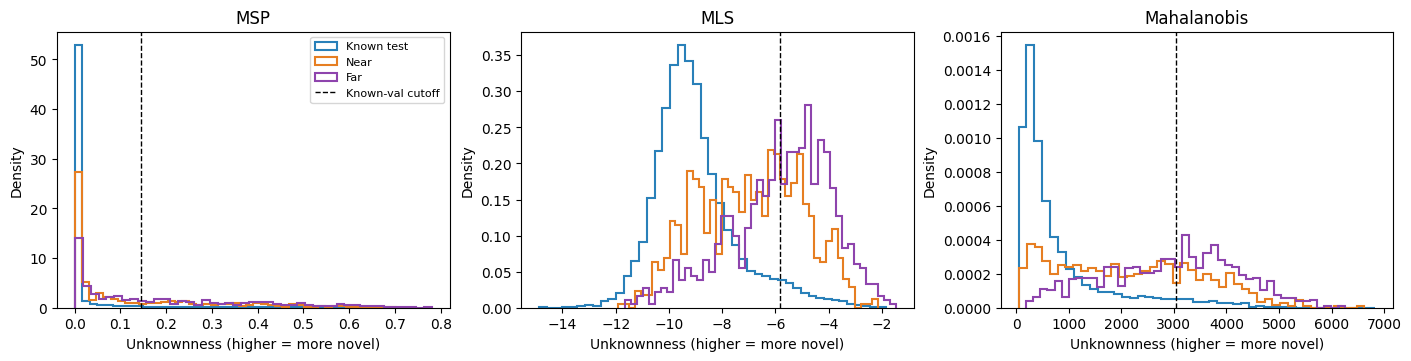

Which unknown classes pass the frozen Vanilla MLS threshold?


,Group,Unknown class,Accepted / total,Acceptance rate,Most frequent known prediction
9,Far,bowl,53 / 100,0.53,cat
13,Far,mushroom,50 / 100,0.50,bird
10,Far,chair,48 / 100,0.48,airplane
14,Far,sunflower,47 / 100,0.47,bird
15,Far,wardrobe,46 / 100,0.46,truck
11,Far,clock,38 / 100,0.38,cat
8,Far,bottle,37 / 100,0.37,cat
12,Far,keyboard,35 / 100,0.35,airplane
5,Near,pickup_truck,90 / 100,0.90,automobile
0,Near,bus,89 / 100,0.89,truck


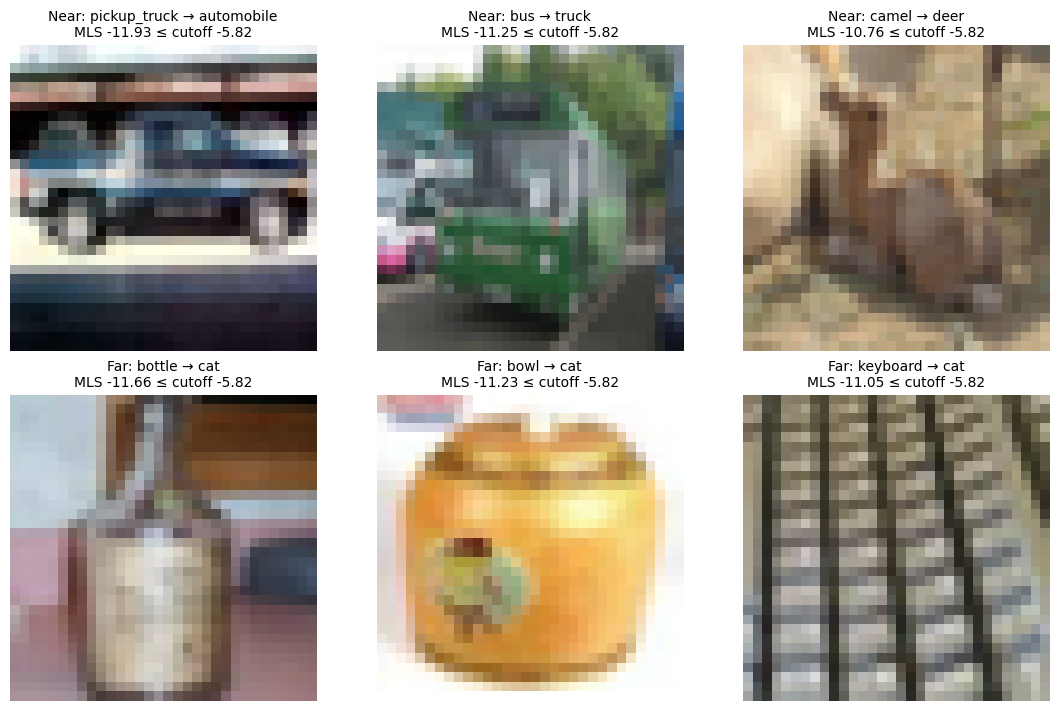

,Group,CIFAR-100 test id,Unknown class,Known prediction,MLS unknownness,Threshold,Interpretation
0,Near,7658,pickup_truck,automobile,-11.931,-5.82,plausible semantic overlap
1,Near,4185,bus,truck,-11.254,-5.82,plausible semantic overlap
2,Near,7445,camel,deer,-10.756,-5.82,plausible semantic overlap
3,Far,3888,bottle,cat,-11.664,-5.82,surprising cross-category acceptance
4,Far,2797,bowl,cat,-11.235,-5.82,surprising cross-category acceptance
5,Far,3586,keyboard,cat,-11.048,-5.82,surprising cross-category acceptance


In [ ]:
fig,axes=plt.subplots(1,3,figsize=(14,3.5),layout='constrained')
for ax,s in zip(axes,['MSP','MLS','Mahalanobis']):
    for label,values,color in [('Known test',vscore_test[s],'#2980b9'),('Near',vscore_near[s],'#e67e22'),('Far',vscore_far[s],'#8e44ad')]:
        ax.hist(values,bins=45,density=True,histtype='step',linewidth=1.5,color=color,label=label)
    ax.axvline(thresholds['Vanilla '+s],color='black',linestyle='--',linewidth=1,label='Known-val cutoff')
    ax.set_title(s); ax.set_xlabel('Unknownness (higher = more novel)');ax.set_ylabel('Density')
axes[0].legend(fontsize=8)
fig.savefig(RESULTS/'vanilla_score_distributions.png',dpi=180,bbox_inches='tight')
plt.show()

failure_rows=[]; examples={}
for group,arr,vals in [('Near',vnear,vscore_near['MLS']),('Far',vfar,vscore_far['MLS'])]:
    accepted=np.flatnonzero(vals<=thresholds['Vanilla MLS'])
    assert len(accepted)>=3,f'Fewer than three accepted {group} unknowns; report actual count rather than replacing threshold.'
    classes100=np.asarray([c100.classes[int(c)] for c in arr['labels']])
    preds=arr['logits'][:,:10].argmax(1)
    for klass in sorted(set(classes100)):
        positions=np.flatnonzero(classes100==klass)
        taken=positions[vals[positions]<=thresholds['Vanilla MLS']]
        if len(taken):
            counts=pd.Series([classes[int(p)] for p in preds[taken]]).value_counts()
            failure_rows.append({'Group':group,'Unknown class':klass,'Accepted / total':f'{len(taken)} / {len(positions)}',
                                 'Acceptance rate':len(taken)/len(positions),'Most frequent known prediction':counts.index[0]})

    selected=[]
    for klass in sorted(set(classes100[accepted])):
        candidates=accepted[classes100[accepted]==klass]
        selected.append(int(candidates[np.argmin(vals[candidates])]))
    selected=sorted(selected,key=lambda i:vals[i])[:3]
    if len(selected)<3:
        for idx in accepted[np.argsort(vals[accepted])]:
            if int(idx) not in selected: selected.append(int(idx))
            if len(selected)==3: break
    assert len(selected)==3
    examples[group]=selected

class_table=pd.DataFrame(failure_rows).sort_values(['Group','Acceptance rate'],ascending=[True,False])
class_table.to_csv(RESULTS/'per_unknown_class_acceptance.csv',index=False)
print('Which unknown classes pass the frozen Vanilla MLS threshold?')
display(class_table)

fig,axes=plt.subplots(2,3,figsize=(11,7),layout='constrained')
show_rows=[]
for r,(group,arr,values) in enumerate([('Near',vnear,vscore_near['MLS']),('Far',vfar,vscore_far['MLS'])]):
    for col,i in enumerate(examples[group]):
        fine=c100.classes[int(arr['labels'][i])]
        pred=classes[int(arr['logits'][i,:10].argmax())]
        score=float(values[i]); tau=thresholds['Vanilla MLS']
        axes[r,col].imshow(c100.data[int(arr['ids'][i])]); axes[r,col].axis('off')
        axes[r,col].set_title(f'{group}: {fine} → {pred}\nMLS {score:.2f} ≤ cutoff {tau:.2f}',fontsize=10)
        show_rows.append({'Group':group,'CIFAR-100 test id':int(arr['ids'][i]),'Unknown class':fine,
                          'Known prediction':pred,'MLS unknownness':score,'Threshold':tau,
                          'Interpretation':'plausible semantic overlap' if group=='Near' else 'surprising cross-category acceptance'})
fig.savefig(RESULTS/'six_accepted_unknowns.png',dpi=180,bbox_inches='tight')
plt.show()
examples_table=pd.DataFrame(show_rows)
examples_table.to_csv(RESULTS/'six_accepted_unknowns.csv',index=False)
display(examples_table.round(3))


## 7. Data For Research Questions


In [ ]:
comp=pd.DataFrame(model_rows).set_index(['Model','Score'])
van=comp.loc[('Vanilla','MLS')]
for model in ['GCSC','PROSER']:
    target=comp.loc[(model,'MLS')]
    print(f'{model} − Vanilla MLS: CSA {100*(target["CSA"]-van["CSA"]):+.2f} points; '
          f'near AUROC {100*(target["AUROC near"]-van["AUROC near"]):+.2f} points; '
          f'far AUROC {100*(target["AUROC far"]-van["AUROC far"]):+.2f} points; '
          f'near reject {100*(target["Near reject"]-van["Near reject"]):+.2f} points; '
          f'far reject {100*(target["Far reject"]-van["Far reject"]):+.2f} points')
placeholder=comp.loc[('PROSER','placeholder')]
proser_mls=comp.loc[('PROSER','MLS')]
print(f'PROSER placeholder − PROSER MLS: near AUROC {100*(placeholder["AUROC near"]-proser_mls["AUROC near"]):+.2f} points; '
      f'far AUROC {100*(placeholder["AUROC far"]-proser_mls["AUROC far"]):+.2f} points')
rank_corr=pd.DataFrame({k:np.concatenate([vscore_near[k],vscore_far[k]]) for k in vscore_test}).corr(method='spearman')
rank_corr.to_csv(RESULTS/'vanilla_score_rank_correlation.csv')
print('Vanilla score rank agreement on the 1,600 fixed unknown test images:')
display(rank_corr.round(3))
from scipy.stats import rankdata
joined={s:np.concatenate([vscore_near[s],vscore_far[s]]) for s in vscore_test}
rank_gap=np.abs(rankdata(joined['MSP'])-rankdata(joined['MLS']))
disagree=[]
for i in np.argsort(rank_gap)[-6:][::-1]:
    group,local=('Near',int(i)) if i<len(vnear['ids']) else ('Far',int(i)-len(vnear['ids']))
    arr=vnear if group=='Near' else vfar
    disagree.append({'Group':group,'Unknown class':c100.classes[int(arr['labels'][local])],
                     'Known prediction':classes[int(arr['logits'][local,:10].argmax())],
                     'MSP':joined['MSP'][i],'MLS':joined['MLS'][i],
                     'Energy':joined['Energy'][i],'Mahalanobis':joined['Mahalanobis'][i],
                     'MSP versus MLS rank gap':rank_gap[i]})
disagreement_table=pd.DataFrame(disagree)
disagreement_table.to_csv(RESULTS/'score_rank_disagreements.csv',index=False)
print('Examples on which relative confidence (MSP) and logit magnitude (MLS) disagree most:')
display(disagreement_table.round(3))
for group in ('Near','Far'):
    print(group,'most often accepted classes and absorbing known labels:')
    display(class_table[class_table['Group']==group].head(4))
print('Interpret score differences using the frozen tables: MSP = relative class confidence; MLS = absolute top logit; '
      'Energy = evidence across logits; Mahalanobis = distance from training feature clusters. '
      'PROSER mixups cover boundaries between known classes, not every unseen direction. '
      'AUROC measures ranking; validation-calibrated rejection measures the specified operating point.')
(RESULTS/'environment.json').write_text(json.dumps({'torch':torch.__version__,'torchvision':torchvision.__version__,
    'python':platform.python_version(),'device':torch.cuda.get_device_name(0),'seed':SEED},indent=2))
print('Saved checkpoints, split and unknown IDs, frozen protocol, features/logits, tables, figures, and inspected cases to',ROOT)


GCSC − Vanilla MLS: CSA +0.22 points; near AUROC +0.89 points; far AUROC +2.67 points; near reject +0.13 points; far reject +4.37 points
PROSER − Vanilla MLS: CSA -0.35 points; near AUROC -1.26 points; far AUROC -1.86 points; near reject -1.00 points; far reject -4.87 points
PROSER placeholder − PROSER MLS: near AUROC -1.48 points; far AUROC +1.68 points
Vanilla score rank agreement on the 1,600 fixed unknown test images:


,MSP,MLS,Energy,Mahalanobis
MSP,1.000,0.920,0.890,0.937
MLS,0.920,1.000,0.996,0.850
Energy,0.890,0.996,1.000,0.822
Mahalanobis,0.937,0.850,0.822,1.000


Examples on which relative confidence (MSP) and logit magnitude (MLS) disagree most:


,Group,Unknown class,Known prediction,MSP,MLS,Energy,Mahalanobis,MSP versus MLS rank gap
0,Far,mushroom,cat,0.260,-7.788,-8.090,4089.839,795.0
1,Near,wolf,cat,0.365,-7.070,-7.525,3470.899,789.0
2,Near,fox,cat,0.248,-7.699,-7.984,3701.507,756.0
3,Near,camel,deer,0.492,-6.315,-6.993,4457.210,755.0
4,Near,fox,cat,0.287,-7.460,-7.798,3708.634,753.0
5,Near,fox,cat,0.424,-6.484,-7.036,3892.422,726.0


Near most often accepted classes and absorbing known labels:


,Group,Unknown class,Accepted / total,Acceptance rate,Most frequent known prediction
5,Near,pickup_truck,90 / 100,0.90,automobile
0,Near,bus,89 / 100,0.89,truck
7,Near,wolf,75 / 100,0.75,cat
3,Near,leopard,65 / 100,0.65,cat


Far most often accepted classes and absorbing known labels:


,Group,Unknown class,Accepted / total,Acceptance rate,Most frequent known prediction
9,Far,bowl,53 / 100,0.53,cat
13,Far,mushroom,50 / 100,0.50,bird
10,Far,chair,48 / 100,0.48,airplane
14,Far,sunflower,47 / 100,0.47,bird


Interpret score differences using the frozen tables: MSP = relative class confidence; MLS = absolute top logit; Energy = evidence across logits; Mahalanobis = distance from training feature clusters. PROSER mixups cover boundaries between known classes, not every unseen direction. AUROC measures ranking; validation-calibrated rejection measures the specified operating point.
Saved checkpoints, split and unknown IDs, frozen protocol, features/logits, tables, figures, and inspected cases to /content/drive/MyDrive/ATML_PA1/Task4_CIFAR_OSR
